# 02d — Möbius / disk automorphism (hyperbolic centering)

Applies a **Poincaré-disk automorphism** `T(z) = (z - z0) / (1 - conj(z0) * z)` with `z0` the focus protein's orthographic disk point, so **`T(z0) = 0`**. All positions and geodesic endpoints are mapped by `T` before drawing; geodesics remain true hyperbolic geodesics in the unit disk. The boundary stays **`|z| = 1`**.

If the focus lies very near the unit circle (orthographic `|z0| >= 0.998`), the notebook **nudges** `z0` slightly inward and prints a warning so the Blaschke map stays numerically stable. Set **`FOCUS_NODE`** and **`SEED_NODES`** in the last code cell.

**Why many lines look straight (vs. 02c):** after the Möbius map, the **focus is at the origin** of the Poincaré disk. Geodesics **through the center** are **Euclidean straight segments** (diameters). Every edge **incident to `FOCUS_NODE`** has one mapped endpoint at ~0, so those geodesics are straight radii.

**Straight without looking “through” the center:** if both mapped endpoints lie on the **same line through the origin** (same angle, both on one side of 0), the hyperbolic geodesic is still that **Euclidean line segment**—it is part of a diameter but the segment **need not contain** 0. After a hub-centered map, many partners can sit in a **tight angular sector**, so lots of edges are **nearly collinear** with 0 and read as straight.

**Also:** very **short** arcs look straight at screen resolution, and **many overlapping** edges can merge into a ruled texture. Increase `n` in `poincare_geodesic_xy(..., n=...)` if polylines look faceted.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 200

import dmercator_io as dm

RUN_SUBDIR = "d2"
RUN_SUBDIR = os.environ.get("DMERCATOR_RUN", RUN_SUBDIR)
paths = dm.paths_for_run(RUN_SUBDIR)
_, df = dm.parse_inf_coord(paths["inf_coord"])
G = dm.load_edges_graph(paths["edge"])

xO, yO = dm.ortho_xy_disk(df)
pos_idx = {v: i for i, v in enumerate(df["Vertex"])}
print("RUN_SUBDIR:", RUN_SUBDIR, "|V|=", len(pos_idx), "|E|=", G.number_of_edges())

RUN_SUBDIR: d2 |V|= 17090 |E|= 298866


In [2]:
# Poincaré disk ↔ upper half-plane geodesics (orthographic disk z = x + iy)


def _disk_to_upper(z: complex) -> complex:
    return 1j * (1 + z) / (1 - z)


def _upper_to_disk(w):
    return (w - 1j) / (w + 1j)


def _halfplane_geodesic_points(u1: complex, u2: complex, n: int):
    u1 = complex(u1)
    u2 = complex(u2)
    if abs(u1 - u2) < 1e-14:
        return np.array([u1], dtype=np.complex128)
    if abs(u1.real - u2.real) < 1e-12 * (1.0 + abs(u1.imag) + abs(u2.imag)):
        im = np.linspace(u1.imag, u2.imag, n)
        return u1.real + 1j * im
    denom = 2.0 * (u2.real - u1.real)
    c = (abs(u2) ** 2 - abs(u1) ** 2) / denom + 0j
    r = float(abs(u1 - c))
    t1 = np.angle(u1 - c)
    t2 = np.angle(u2 - c)
    delta_short = (t2 - t1 + np.pi) % (2 * np.pi) - np.pi
    # Two arcs along the full circle; the hyperbolic geodesic stays in Im >= 0.
    if abs(delta_short) < 1e-14:
        return np.array([u1, u2], dtype=np.complex128)
    delta_long = delta_short - float(np.copysign(2.0 * np.pi, delta_short))
    for delta in (delta_short, delta_long):
        angles = t1 + np.linspace(0.0, float(delta), n)
        pts = c + r * np.exp(1j * angles)
        if float(np.min(pts.imag)) >= -1e-10:
            return pts
    angles = t1 + np.linspace(0.0, float(delta_short), n)
    return c + r * np.exp(1j * angles)


def poincare_geodesic_xy(z1, z2, n: int = 96):
    z1 = complex(z1)
    z2 = complex(z2)
    u1 = _disk_to_upper(z1)
    u2 = _disk_to_upper(z2)
    pts_h = _halfplane_geodesic_points(u1, u2, n)
    pts_d = _upper_to_disk(pts_h)
    return pts_d.real, pts_d.imag

FOCUS_NODE mapped to: 0j edges: 1378


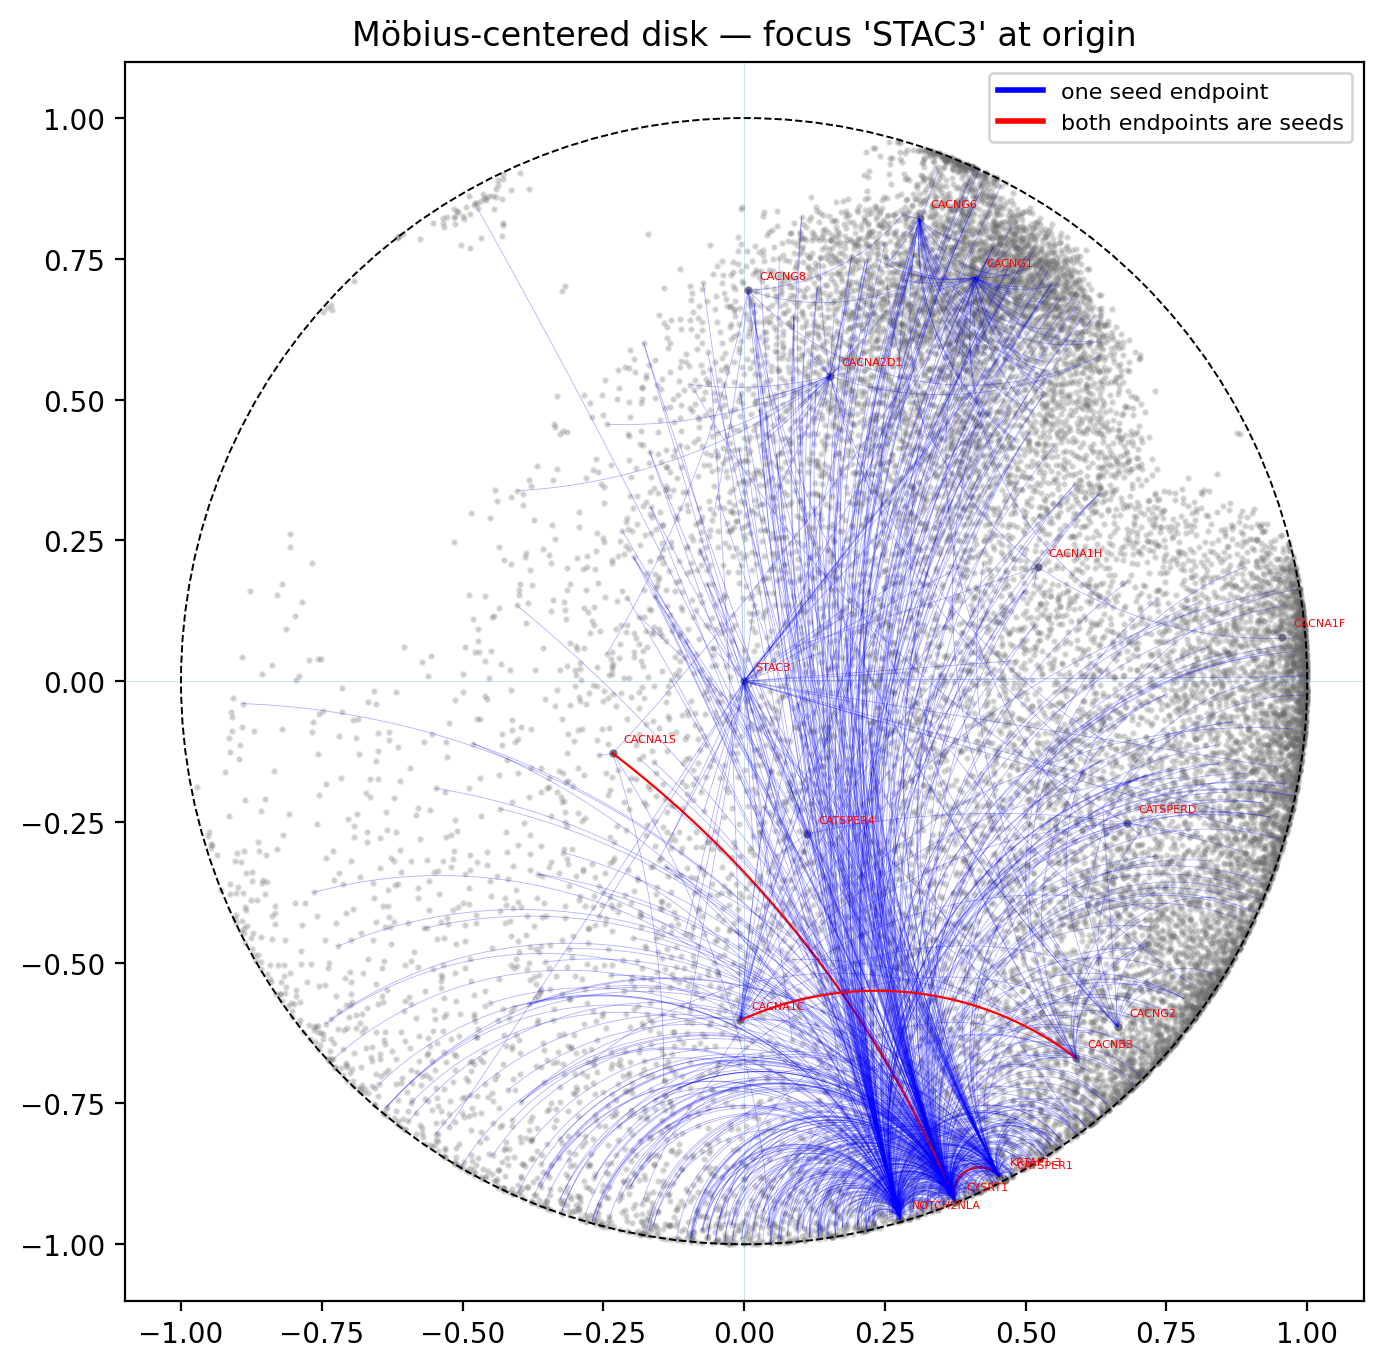

In [7]:
def mobius_focus_to_origin(z, z0: complex):
    z = np.asarray(z, dtype=np.complex128)
    z0 = complex(z0)
    return (z - z0) / (1.0 - np.conjugate(z0) * z)


from matplotlib.lines import Line2D

FOCUS_NODE = "STAC3"
SEED_NODES = [
    "CATSPER1",
    "CYSRT1",
    "CATSPERD",
    "CACNA1H",
    "STAC3",
    "CACNB3",
    "CACNG6",
    "CACNA1S",
    "CATSPER4",
    "CACNG8",
    "CACNG2",
    "CACNA1C",
    "KRTAP1-3",
    "NOTCH2NLA",
    "CACNG1",
    "CACNA1F",
    "CACNA2D1",
]

if FOCUS_NODE.strip() not in pos_idx:
    raise ValueError(f"FOCUS_NODE not in graph/coords: {FOCUS_NODE!r}")
fj = pos_idx[FOCUS_NODE.strip()]
z0_raw = complex(xO[fj], yO[fj])
r0 = abs(z0_raw)
R_SAFE = 0.998  # Blaschke factor needs |z0| < 1 with margin
if r0 < 1e-12:
    raise ValueError("FOCUS_NODE orthographic disk point is ~0; pick another protein")
if r0 >= R_SAFE:
    z0 = z0_raw * (R_SAFE / r0)
    print(
        f"WARN: |z0|={r0:.6f} for {FOCUS_NODE!r} (near unit circle); using nudged |z0|={abs(z0):.6f} for stable Möbius map"
    )
else:
    z0 = z0_raw

Z_all = xO + 1j * yO
W_all = mobius_focus_to_origin(Z_all, z0)

seeds_valid = [str(n).strip() for n in SEED_NODES if str(n).strip()]
missing = [n for n in seeds_valid if n not in pos_idx]
seeds_ok = [n for n in seeds_valid if n in pos_idx]
seed_set = set(seeds_ok)
if missing:
    print("Unknown seeds (skipped):", missing)
if not seeds_ok:
    raise ValueError("No valid SEED_NODES")

edge_rows = []
for a, b in G.edges():
    if a not in pos_idx or b not in pos_idx:
        continue
    a_in, b_in = a in seed_set, b in seed_set
    if not (a_in or b_in):
        continue
    edge_rows.append((a, b, a_in and b_in))

_node_keys = df["Vertex"].to_numpy()
_is_seed = np.array([str(v).strip() in seed_set for v in _node_keys], dtype=bool)
_s_node = 2.0

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    W_all.real[~_is_seed],
    W_all.imag[~_is_seed],
    s=_s_node,
    alpha=0.2,
    c="0.4",
)
ax.scatter(
    W_all.real[_is_seed],
    W_all.imag[_is_seed],
    s=2.0 * _s_node,
    alpha=0.8,
    c="0.4",
)
col_single = "blue"
col_both = "red"
for a, b, both in edge_rows:
    ia, ib = pos_idx[a], pos_idx[b]
    z1 = complex(xO[ia], yO[ia])
    z2 = complex(xO[ib], yO[ib])
    if abs(z1) >= 0.999 or abs(z2) >= 0.999:
        continue
    w1 = complex(mobius_focus_to_origin(z1, z0))
    w2 = complex(mobius_focus_to_origin(z2, z0))
    if abs(w1) >= 0.999 or abs(w2) >= 0.999:
        continue
    gx, gy = poincare_geodesic_xy(w1, w2, n=96)
    ax.plot(gx, gy, lw=0.8 if both else 0.3, alpha=1.0 if both else 0.3, color=col_both if both else col_single)

ax.set_aspect("equal")
ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, ls="--", lw=0.7))
ax.axhline(0, lw=0.3, alpha=0.25)
ax.axvline(0, lw=0.3, alpha=0.25)
ax.set_title("Möbius-centered disk — focus " + repr(FOCUS_NODE.strip()) + " at origin")
ax.legend(
    handles=[
        Line2D([0], [0], color=col_single, lw=2, label="one seed endpoint"),
        Line2D([0], [0], color=col_both, lw=2, label="both endpoints are seeds"),
    ],
    loc="upper right",
    fontsize=8,
)
for name in seeds_ok:
    j = pos_idx[name]
    w = complex(mobius_focus_to_origin(complex(xO[j], yO[j]), z0))
    ax.annotate(
        name,
        (w.real, w.imag),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=4,
        color="red",
        alpha=1,
       # bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.45", alpha=0.75),
    )
w_focus = complex(mobius_focus_to_origin(z0, z0))
print("FOCUS_NODE mapped to:", w_focus, "edges:", len(edge_rows))
plt.tight_layout()
plt.show()